In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Personal imports
sys.path.append("{}/../../../analysis_code/utils".format(os.getcwd()))
from plot_utils import plotly_template
from settings_utils import load_settings

In [2]:
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'RetinoMaps'
subject = 'group'
format_ = '91k'

In [29]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")
settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]

subjects = analysis_info['subjects']
 
analysis_info['rois'] = ['iPCS', 'sPCS', 'mPCS', 'iIPS', 'sIPS']
corr_types = ['full_corr', 'partial_corr']

# Function

In [30]:
def prf_contra_corr_violins_plot(cor_r_lh_df, cor_r_rh_df, figure_info):
    """
    Make split violin plots (LH top / RH bottom) of partial correlation
    between seed and target ROIs

    Parameters
    ----------
    cor_r_lh_df : dataframe, partial corr values, left hemisphere
    cor_r_rh_df : dataframe, partial corr values, right hemisphere
    figure_info : dict with figure settings

    Returns
    -------
    fig : violins plot
    """

    # General figure settings
    template_specs = dict(axes_color="rgba(0, 0, 0, 1)",
                          axes_width=2,
                          axes_font_size=15,
                          bg_col="rgba(255, 255, 255, 1)",
                          font='Arial',
                          title_font_size=15,
                          rois_plot_width=1.5)

    fig_template = plotly_template(template_specs)

    rows = 1
    cols = len(figure_info['rois'])

    rois = figure_info['rois']
    roi_colors = figure_info['roi_colors']
    fig_margin = figure_info['rois_fig_margin']
    hor_spacing_val = figure_info['rois_hor_spacing']
    ver_spacing_val = figure_info['rois_ver_spacing']
    bar_width = figure_info['rois_bar_width']
    plot_height = figure_info['rois_plot_height']

    corr_range = [-0.8, 0.8]
    tickvals = [-0.4, 0, 0.4, 0.8]  # 4 ticks, 0 inclus, dernier tick = bord du range
    alpha_lh = 1
    alpha_rh = 0.4

    def rgba_col(rgb_str, alpha):
        r, g, b = rgb_str[4:-1].split(',')
        return 'rgba({},{},{},{})'.format(r.strip(), g.strip(), b.strip(), alpha)

    fig_height = plot_height * rows + fig_margin[1] + fig_margin[3] + (ver_spacing_val * (rows - 1))
    fig_width = bar_width * cols * len(rois) + fig_margin[0] + fig_margin[2] + (hor_spacing_val * (cols - 1))
    hor_spacing = hor_spacing_val / (fig_width - fig_margin[0] - fig_margin[2])
    ver_spacing = ver_spacing_val / (fig_height - fig_margin[1] - fig_margin[3])

    fig = make_subplots(rows=rows,
                        cols=cols,
                        print_grid=False,
                        vertical_spacing=ver_spacing,
                        horizontal_spacing=hor_spacing,
                        subplot_titles=['{} target'.format(target) for target in rois])

    for col, target in enumerate(rois, start=1):

        for seed in rois:
            if seed == target:
                continue

            color = roi_colors[seed]
            vals_lh = cor_r_lh_df.loc[cor_r_lh_df.seed == seed, target]
            vals_rh = cor_r_rh_df.loc[cor_r_rh_df.seed == seed, target]

            # left hemisphere (top half)
            fig.add_trace(go.Violin(x=vals_lh,
                                    y=[seed] * len(vals_lh),
                                    orientation='h',
                                    side='positive',
                                    name=seed,
                                    showlegend=False,
                                    points='all',
                                    pointpos=0,
                                    jitter=0.5,
                                    marker=dict(size=3, color='black'),
                                    meanline=dict(visible=True, color='black', width=2),
                                    scalemode='width',
                                    fillcolor=rgba_col(color, alpha_lh),
                                    # line_color=color,
                                    line_color='rgba(0,0,0,0)'
                                   ),
                          row=1, col=col)

            # right hemisphere (bottom half)
            fig.add_trace(go.Violin(x=vals_rh,
                                    y=[seed] * len(vals_rh),
                                    orientation='h',
                                    side='negative',
                                    name=seed,
                                    showlegend=False,
                                    points='all',
                                    pointpos=0,
                                    jitter=0.5,
                                    marker=dict(size=3, color='black'),
                                    meanline=dict(visible=True, color='black', width=2),
                                    scalemode='width',
                                    fillcolor=rgba_col(color, alpha_rh),
                                    # line_color=rgba_col(color, alpha_rh)
                                    line_color='rgba(0,0,0,0)'
                                   ),
                          row=1, col=col)

        # grey band for the seed == target row (no data)
        y_idx = rois.index(target)
        fig.add_shape(type='rect',
                     xref='x{}'.format(col) if col > 1 else 'x',
                     yref='y{}'.format(col) if col > 1 else 'y',
                     x0=corr_range[0], x1=corr_range[1],
                     y0=y_idx - 0.5, y1=y_idx + 0.5,
                     fillcolor='rgba(0,0,0,0.08)',
                     line_width=0,
                     layer='below')

        # Set axis titles only for the left-most column
        fig.update_yaxes(showline=True,
                         categoryorder='array',
                         categoryarray=rois,
                         title_text='seed' if col == 1 else None,
                         row=1, col=col)



        fig.update_xaxes(showline=True,
                         range=corr_range,
                         tickmode='array',
                         tickvals=tickvals,
                         ticks='outside',
                         ticklen=8,
                         tickcolor=template_specs['axes_color'],
                         tickwidth=template_specs['axes_width'],
                         showticklabels=True,
                         zeroline=True,
                         zerolinecolor=template_specs['axes_color'],
                         row=1, col=col)

    fig.update_layout(height=fig_height,
                      width=fig_width,
                      showlegend=False,
                      legend=dict(orientation="h",
                                  font_family=template_specs['font'],
                                  font_size=template_specs['axes_font_size'],
                                  y=1.1,
                                  yanchor='top',
                                  xanchor='left',
                                  traceorder='normal',
                                  itemwidth=30),
                      template=fig_template,
                      margin_l=fig_margin[0],
                      margin_t=fig_margin[1],
                      margin_r=fig_margin[2],
                      margin_b=fig_margin[3]
                     )

    return fig

# Plots

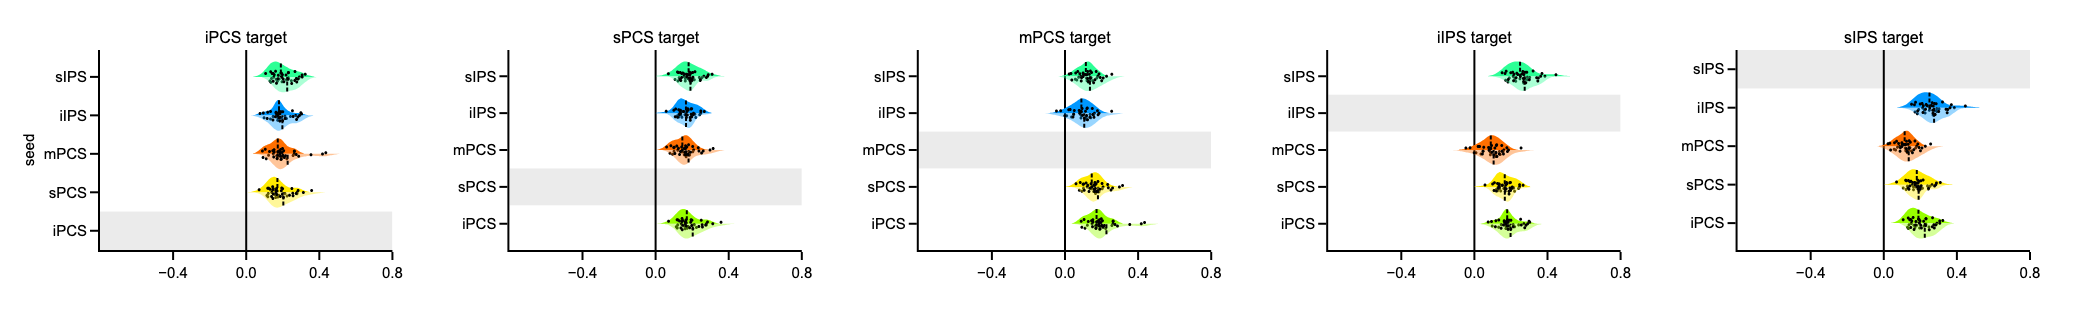

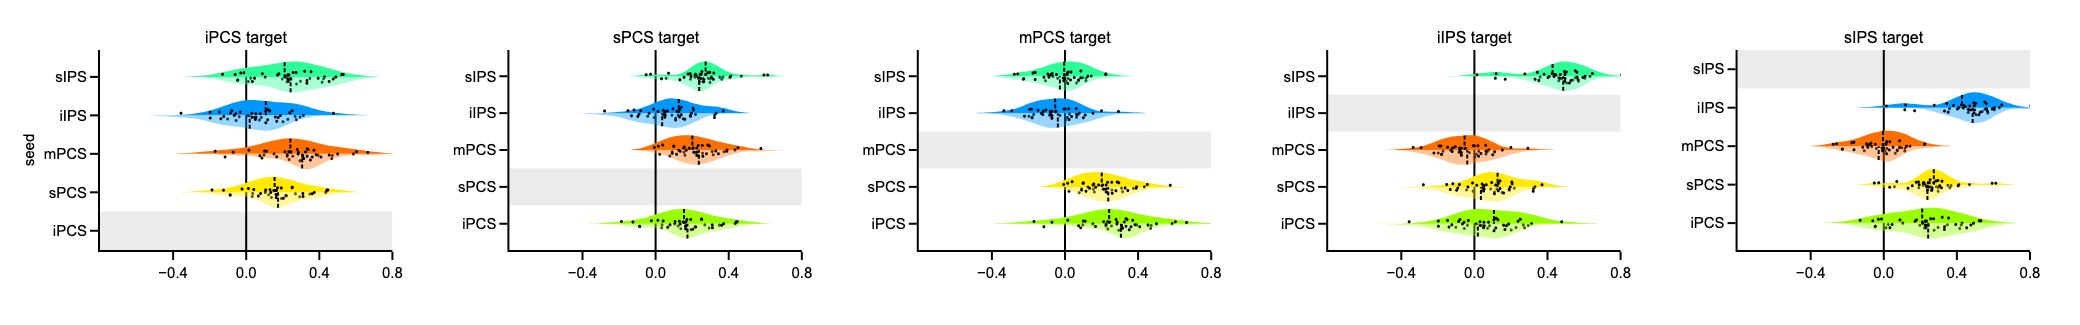

In [31]:
for corr_type in corr_types :
    if corr_type == 'full_corr': 
        corr_type2 = 'full-corr' 
        suffix = '_legacy'
    elif corr_type == 'partial_corr': 
        corr_type2 = 'partial-corr'
        suffix = ''

    cor_dir = '{}/{}/derivatives/pp_data/{}/{}/rest/{}/tables'.format(main_dir, project_dir, subject, format_, corr_type)
    cor_r_lh_fn = '{}/seed-task_by_macror-task_{}_r_report_ipsi_lh{}.tsv'.format(cor_dir, corr_type2, suffix)
    cor_r_rh_fn = '{}/seed-task_by_macror-task_{}_r_report_ipsi_rh{}.tsv'.format(cor_dir, corr_type2, suffix)

    cor_r_lh_df = pd.read_table(cor_r_lh_fn, sep="\t")
    cor_r_rh_df = pd.read_table(cor_r_rh_fn, sep="\t")


    fig = prf_contra_corr_violins_plot(cor_r_lh_df=cor_r_lh_df, cor_r_rh_df=cor_r_rh_df, figure_info=analysis_info)

    fig_dir = '/Users/uriel/Library/CloudStorage/Dropbox/retinomaps/figures/material/resting_state/violins'
    fig_fn = "{}/{}_violons.pdf".format(fig_dir, corr_type)
    fig.write_image(fig_fn)
    fig.show()

In [16]:
analysis_info['roi_colors']

{'V1': 'rgb(243, 231, 155)',
 'V2': 'rgb(250, 196, 132)',
 'V3': 'rgb(248, 160, 126)',
 'V3AB': 'rgb(235, 127, 134)',
 'LO': 'rgb(150, 0, 90)',
 'VO': 'rgb(0, 0, 200)',
 'hMT+': 'rgb(0, 25, 255)',
 'iIPS': 'rgb(0, 152, 255)',
 'sIPS': 'rgb(44, 255, 150)',
 'iPCS': 'rgb(151, 255, 0)',
 'sPCS': 'rgb(255, 234, 0)',
 'mPCS': 'rgb(255, 111, 0)'}

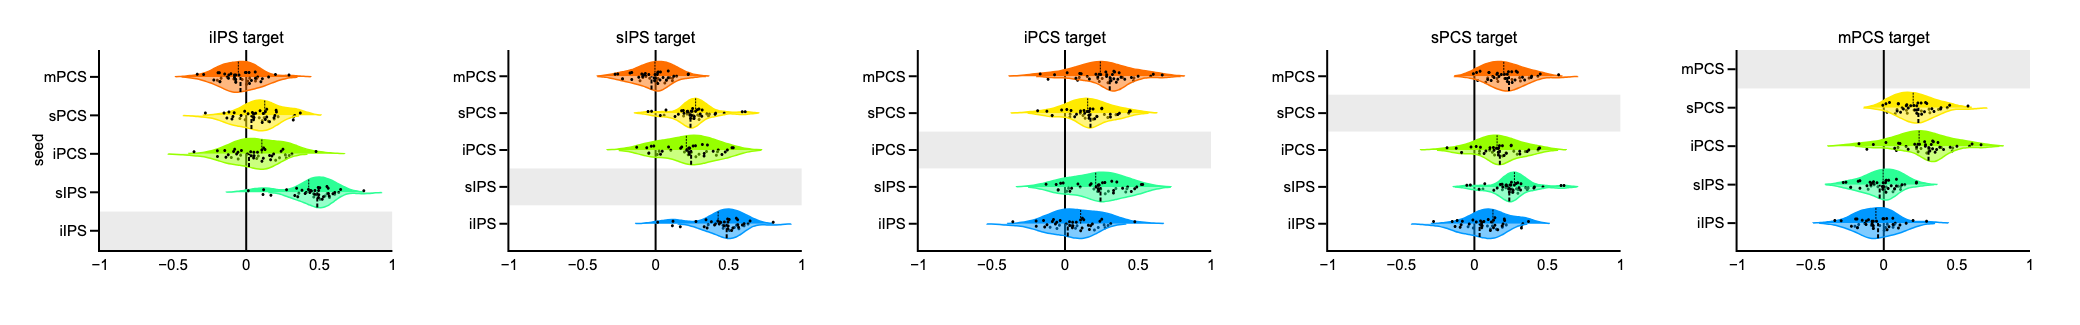

In [24]:
fig = prf_contra_corr_violins_plot(cor_r_lh_df=cor_r_lh_df, cor_r_rh_df=cor_r_rh_df, figure_info=analysis_info)

fig_dir = '/Users/uriel/Library/CloudStorage/Dropbox/retinomaps/figures/material/resting_state/violins'
fig_fn = "{}/{}_violons.pdf".format(fig_dir, corr_type)
fig.write_image(fig_fn)
fig.show()

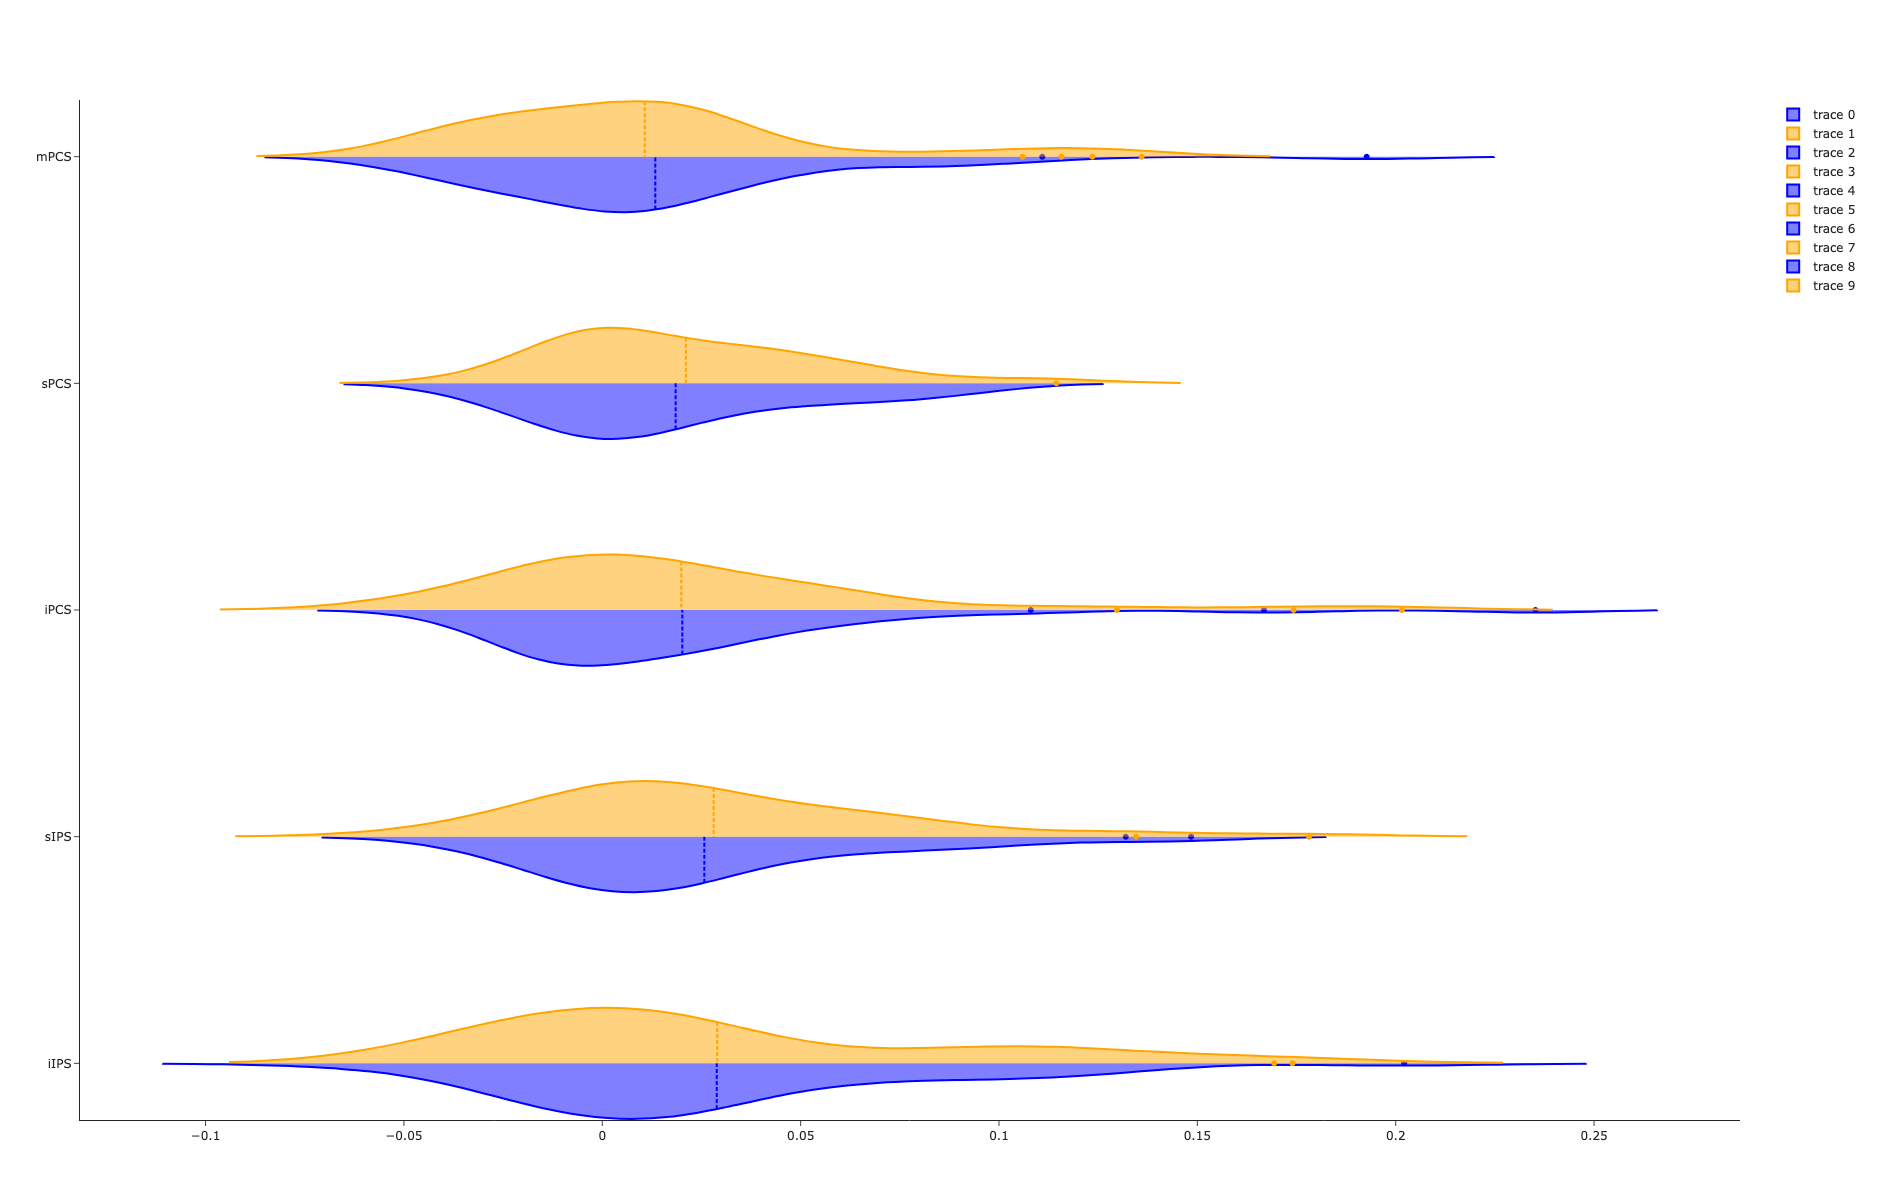

In [40]:
fig = go.Figure()

for roi_num, roi in enumerate(rois):

    roi_cor_r_lh_df = cor_r_lh_df.loc[cor_r_lh_df['Unnamed: 0'] == roi]
    roi_cor_r_rh_df = cor_r_rh_df.loc[cor_r_rh_df['Unnamed: 0'] == roi]

    lh_values = roi_cor_r_lh_df.drop(columns='Unnamed: 0').iloc[0].to_numpy()
    rh_values = roi_cor_r_rh_df.drop(columns='Unnamed: 0').iloc[0].to_numpy()

    fig.add_trace(
        go.Violin(
            x=lh_values,
            y=[roi] * len(lh_values),
            side='negative',
            line_color='blue',
            orientation='h'
        )
    )

    fig.add_trace(
        go.Violin(
            x=rh_values,
            y=[roi] * len(rh_values),
            side='positive',
            line_color='orange',
            orientation='h'
        )
    )

fig.update_traces(meanline_visible=True)

fig.update_layout(
    template='simple_white',
    height=1200,
    width=1400,
    violinmode='overlay'
)

fig.show()

In [41]:
cor_r_lh_df

,Unnamed: 0,SCEF,p32pr,24dv,FEF,i6-8,6a,6d,6mp,6ma,...,LO1,LO2,LO3,V3A,V3B,V3CD,V3,V4,V2,V1
0,mPCS,NaN,NaN,NaN,0.078002,-0.024935,0.003245,0.010530,0.110923,0.088894,...,0.034002,0.029248,-0.031711,0.014625,0.071846,-0.052820,-0.010027,-0.037228,0.010798,0.035758
1,sPCS,0.093596,0.054600,0.050674,NaN,NaN,NaN,NaN,NaN,NaN,...,0.004324,-0.013137,0.017347,0.007280,-0.004598,0.007964,-0.010560,-0.009701,-0.025104,0.027295
2,iPCS,0.235218,0.050264,-0.014319,0.108011,-0.012331,0.067931,0.064253,-0.010106,0.022880,...,-0.013680,-0.027590,0.005871,-0.008433,0.008407,-0.014237,-0.016163,-0.040946,0.029876,0.005138
3,sIPS,-0.012119,0.021308,-0.036599,0.075858,-0.035298,0.103452,0.031193,0.013397,0.030467,...,0.004233,0.012525,0.036450,0.027529,0.006563,0.011445,0.001455,0.019348,-0.008021,-0.004087
4,iIPS,-0.002234,0.011220,0.014423,0.028431,-0.019693,0.081618,0.032199,-0.028122,0.000003,...,0.026690,-0.064948,0.057101,0.082863,0.121367,0.114848,-0.016783,0.012215,-0.021309,0.014471
5,hMT+,-0.032306,-0.030287,-0.000226,-0.006573,-0.004306,-0.021926,-0.000119,0.046427,0.023584,...,0.062855,0.122252,0.106210,0.056775,0.016995,-0.020478,0.022606,0.051033,-0.001249,-0.022789
6,VO,-0.010132,0.015296,0.008908,-0.016130,0.032220,-0.008301,0.002441,0.015834,0.016158,...,0.046464,0.141350,0.010831,-0.020142,0.029218,0.059019,0.008562,0.159302,0.042408,0.045081
7,LO,0.036871,-0.018607,-0.030862,0.009604,0.008792,-0.009908,-0.014864,0.011567,-0.024239,...,NaN,NaN,NaN,0.074923,0.040567,0.209447,0.045684,0.117005,0.006030,-0.004409
8,V3AB,0.001542,-0.023448,-0.015754,0.014494,-0.020805,-0.007602,-0.010027,-0.001262,0.014422,...,0.070830,0.060015,0.094343,NaN,NaN,NaN,0.118157,0.106822,0.072702,0.027092
9,V3,-0.012292,-0.020712,-0.025129,-0.002550,0.028834,0.007607,0.014587,0.001716,0.013303,...,0.102297,0.116054,-0.037020,0.094200,0.051359,0.060618,NaN,NaN,0.249141,0.075222
